In [1]:
# ============================================
# DCGAN on Fashion-MNIST
# Cell 1: Import Libraries
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils

import matplotlib.pyplot as plt
import numpy as np
import os

print("PyTorch version:", torch.__version__)

# Check whether GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch version: 2.11.0+cu128
Device: cuda


In [2]:
# ============================================
# Cell 2: Load Fashion-MNIST Dataset
# ============================================

# Transform images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load Fashion-MNIST training dataset
dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Create DataLoader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

print("Dataset size:", len(dataset))
print("Number of batches:", len(dataloader))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.8MB/s]

Dataset size: 60000
Number of batches: 469


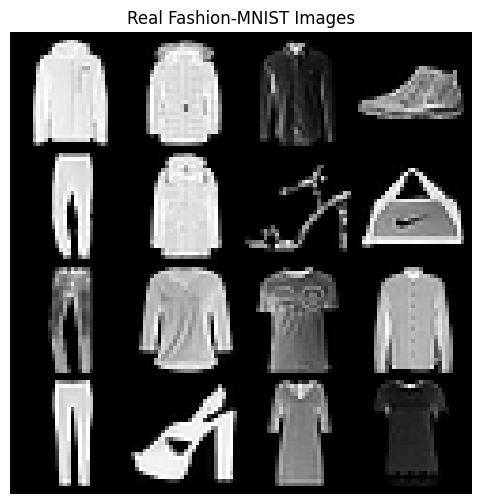

In [3]:
# ============================================
# Cell 3: Visualize Real Images
# ============================================

# Get one batch of images
real_images, labels = next(iter(dataloader))

# Create a 4x4 grid
grid = vutils.make_grid(
    real_images[:16],
    nrow=4,
    normalize=True
)

# Display the images
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)), cmap="gray")
plt.axis("off")
plt.title("Real Fashion-MNIST Images")
plt.show()

In [4]:
# ============================================
# Cell 4: Define the Generator
# ============================================

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # Input: random noise (100, 1, 1)
            nn.ConvTranspose2d(
                100, 256,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Keep image size at 28x28
            nn.Conv2d(
                64, 1,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            # Output values between -1 and 1
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# Create Generator
netG = Generator().to(device)

print(netG)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)


In [5]:
# ============================================
# Cell 5: Test Generator
# ============================================

# Generate random noise
noise = torch.randn(16, 100, 1, 1, device=device)

# Generate fake images
fake_images = netG(noise)

print("Noise shape:", noise.shape)
print("Generated image shape:", fake_images.shape)

Noise shape: torch.Size([16, 100, 1, 1])
Generated image shape: torch.Size([16, 1, 28, 28])


In [8]:
# ============================================
# Cell 6: Define the Discriminator
# ============================================

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # Input: 1 x 28 x 28
            nn.Conv2d(
                1, 64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 28x28 -> 14x14
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 14x14 -> 7x7
            nn.Conv2d(
                128, 256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 7x7 -> 3x3
            nn.Conv2d(
                256, 1,
                kernel_size=3,
                stride=1,
                padding=0,
                bias=False
            ),

            # Output probability
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)


# Create Discriminator
netD = Discriminator().to(device)

print(netD)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)


In [9]:
# ============================================
# Cell 7: Test Discriminator
# ============================================

# Send generated images to the discriminator
output = netD(fake_images)

print("Input image shape:", fake_images.shape)
print("Discriminator output shape:", output.shape)
print("Sample predictions:", output[:5])

Input image shape: torch.Size([16, 1, 28, 28])
Discriminator output shape: torch.Size([16])
Sample predictions: tensor([0.3164, 0.4389, 0.6377, 0.5113, 0.5218], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [10]:
# ============================================
# Cell 8: Loss Function and Optimizers
# ============================================

# Binary Cross Entropy loss
criterion = nn.BCELoss()

# Learning rate
lr = 0.0002

# Adam optimizers
optimizerG = optim.Adam(
    netG.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

optimizerD = optim.Adam(
    netD.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

# Number of epochs
num_epochs = 30

# Fixed noise for comparing generated images
fixed_noise = torch.randn(16, 100, 1, 1, device=device)

print("Loss function: Binary Cross Entropy")
print("Learning rate:", lr)
print("Number of epochs:", num_epochs)
print("Batch size:", 128)

Loss function: Binary Cross Entropy
Learning rate: 0.0002
Number of epochs: 30
Batch size: 128


In [11]:
# ============================================
# Cell 9: Initialize Model Weights
# ============================================

def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# Apply weight initialization
netG.apply(weights_init)
netD.apply(weights_init)

print("Generator and Discriminator weights initialized successfully.")

Generator and Discriminator weights initialized successfully.


In [12]:
# ============================================
# Cell 10: Create Output Folder
# ============================================

os.makedirs("generated_images", exist_ok=True)

print("Output folder created: generated_images")

Output folder created: generated_images


Starting DCGAN Training...
Epoch [1/30] Generator Loss: 2.9312 | Discriminator Loss: 0.7452
Epoch [2/30] Generator Loss: 1.3482 | Discriminator Loss: 0.8768
Epoch [3/30] Generator Loss: 3.4910 | Discriminator Loss: 1.2070
Epoch [4/30] Generator Loss: 1.9932 | Discriminator Loss: 0.5522
Epoch [5/30] Generator Loss: 2.4118 | Discriminator Loss: 0.6950


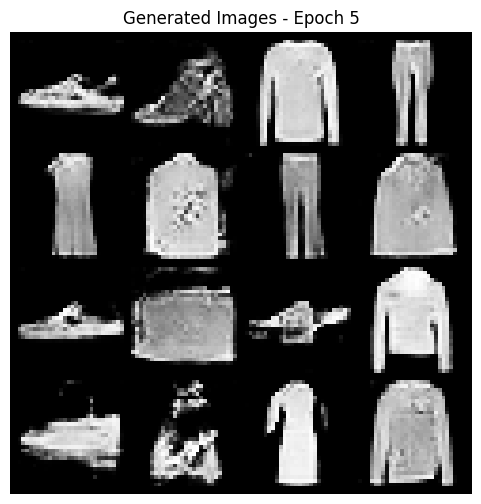

Epoch [6/30] Generator Loss: 1.8386 | Discriminator Loss: 0.6368
Epoch [7/30] Generator Loss: 1.2891 | Discriminator Loss: 0.7592
Epoch [8/30] Generator Loss: 2.1092 | Discriminator Loss: 0.8320
Epoch [9/30] Generator Loss: 1.6828 | Discriminator Loss: 0.8130
Epoch [10/30] Generator Loss: 1.8427 | Discriminator Loss: 0.6716


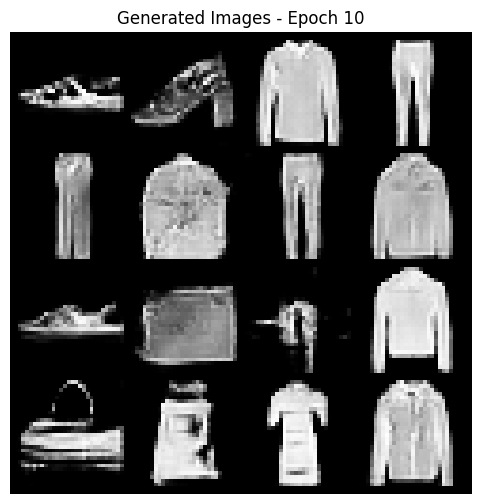

Epoch [11/30] Generator Loss: 1.9643 | Discriminator Loss: 0.6102
Epoch [12/30] Generator Loss: 1.6959 | Discriminator Loss: 0.7410
Epoch [13/30] Generator Loss: 1.2456 | Discriminator Loss: 0.9184
Epoch [14/30] Generator Loss: 3.5324 | Discriminator Loss: 0.9339
Epoch [15/30] Generator Loss: 3.0040 | Discriminator Loss: 0.6886


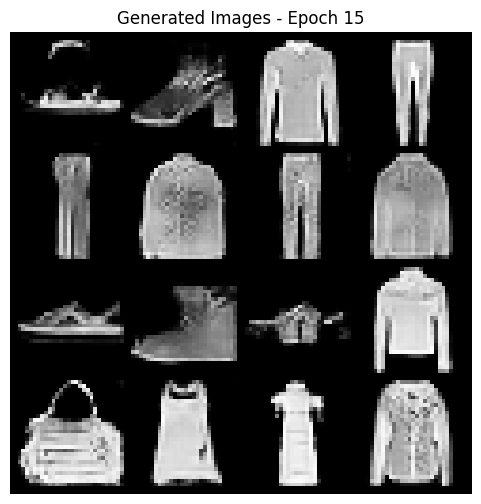

Epoch [16/30] Generator Loss: 1.4901 | Discriminator Loss: 0.7069
Epoch [17/30] Generator Loss: 1.8006 | Discriminator Loss: 0.6348
Epoch [18/30] Generator Loss: 2.8878 | Discriminator Loss: 0.5258
Epoch [19/30] Generator Loss: 2.2719 | Discriminator Loss: 0.6959
Epoch [20/30] Generator Loss: 1.4982 | Discriminator Loss: 0.8808


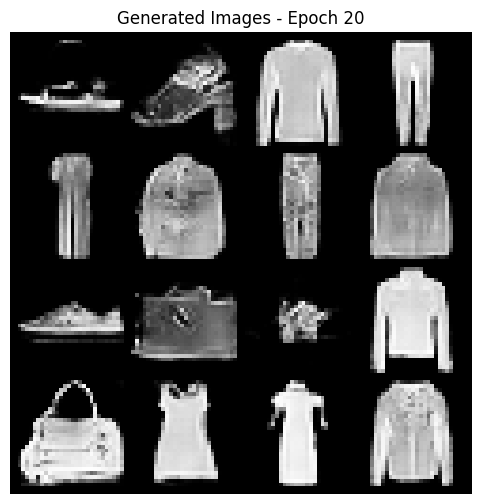

Epoch [21/30] Generator Loss: 2.2892 | Discriminator Loss: 0.6494
Epoch [22/30] Generator Loss: 3.0310 | Discriminator Loss: 0.3103
Epoch [23/30] Generator Loss: 3.1348 | Discriminator Loss: 0.5224
Epoch [24/30] Generator Loss: 1.9242 | Discriminator Loss: 0.7394
Epoch [25/30] Generator Loss: 2.7488 | Discriminator Loss: 0.6543


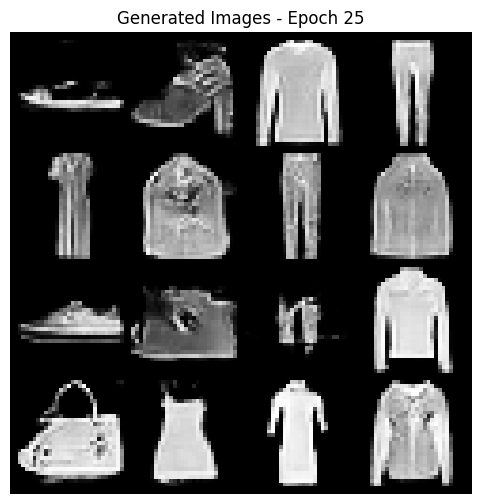

Epoch [26/30] Generator Loss: 2.9562 | Discriminator Loss: 0.5131
Epoch [27/30] Generator Loss: 3.4027 | Discriminator Loss: 0.6175
Epoch [28/30] Generator Loss: 2.1393 | Discriminator Loss: 0.5590
Epoch [29/30] Generator Loss: 3.4136 | Discriminator Loss: 0.5434
Epoch [30/30] Generator Loss: 2.8271 | Discriminator Loss: 0.4814


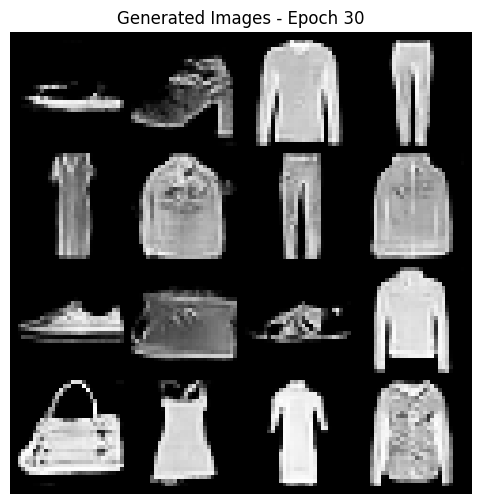

Training completed!


In [13]:
# ============================================
# Cell 11: Train the DCGAN
# ============================================

# Lists to store losses
G_losses = []
D_losses = []

print("Starting DCGAN Training...")
print("=" * 50)

for epoch in range(num_epochs):

    for i, (real_images, _) in enumerate(dataloader):

        # ========================================
        # 1. Train the Discriminator
        # ========================================

        netD.zero_grad()

        # Real images
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Labels for real images = 1
        real_labels = torch.ones(batch_size, device=device)

        # Discriminator prediction for real images
        output_real = netD(real_images)

        # Calculate loss for real images
        loss_D_real = criterion(output_real, real_labels)

        # Generate fake images
        noise = torch.randn(batch_size, 100, 1, 1, device=device)
        fake_images = netG(noise)

        # Labels for fake images = 0
        fake_labels = torch.zeros(batch_size, device=device)

        # Discriminator prediction for fake images
        output_fake = netD(fake_images.detach())

        # Calculate loss for fake images
        loss_D_fake = criterion(output_fake, fake_labels)

        # Total Discriminator loss
        loss_D = loss_D_real + loss_D_fake

        # Backpropagation
        loss_D.backward()

        # Update Discriminator
        optimizerD.step()


        # ========================================
        # 2. Train the Generator
        # ========================================

        netG.zero_grad()

        # We want discriminator to classify fake images as REAL
        generator_labels = torch.ones(batch_size, device=device)

        # Get discriminator prediction
        output_fake_for_G = netD(fake_images)

        # Generator loss
        loss_G = criterion(
            output_fake_for_G,
            generator_labels
        )

        # Backpropagation
        loss_G.backward()

        # Update Generator
        optimizerG.step()


        # ========================================
        # 3. Store losses
        # ========================================

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())


    # ============================================
    # End of Epoch
    # ============================================

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Generator Loss: {loss_G.item():.4f} | "
        f"Discriminator Loss: {loss_D.item():.4f}"
    )


    # ============================================
    # 4. Generate images every 5 epochs
    # ============================================

    if (epoch + 1) % 5 == 0:

        with torch.no_grad():
            generated = netG(fixed_noise).detach().cpu()

        # Create 4x4 image grid
        grid = vutils.make_grid(
            generated,
            nrow=4,
            padding=2,
            normalize=True
        )

        # Save image
        image_path = f"generated_images/epoch_{epoch + 1}.png"

        vutils.save_image(
            generated,
            image_path,
            nrow=4,
            padding=2,
            normalize=True
        )

        # Display image
        plt.figure(figsize=(6, 6))

        plt.imshow(
            np.transpose(
                grid.numpy(),
                (1, 2, 0)
            )
        )

        plt.axis("off")
        plt.title(
            f"Generated Images - Epoch {epoch + 1}"
        )

        plt.show()


print("=" * 50)
print("Training completed!")

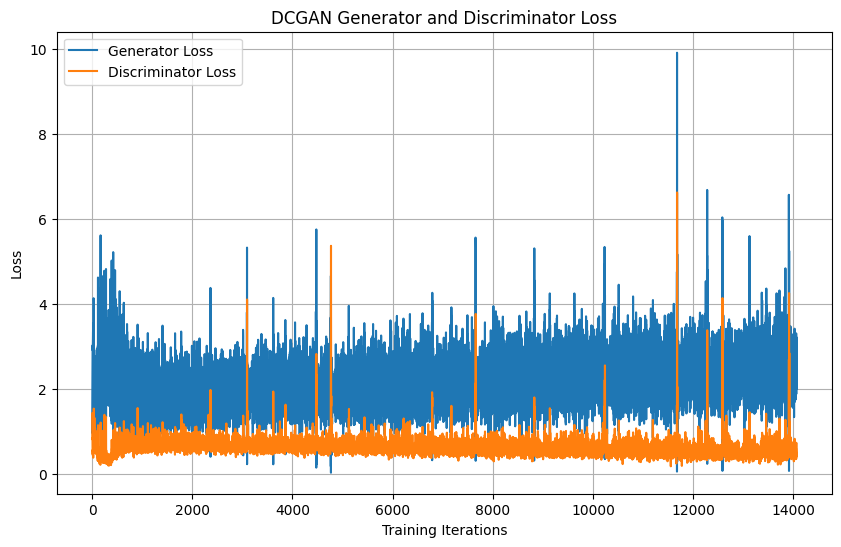

In [14]:
# ============================================
# Cell 12: Plot Generator and Discriminator Loss
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("DCGAN Generator and Discriminator Loss")

plt.legend()
plt.grid(True)

plt.show()

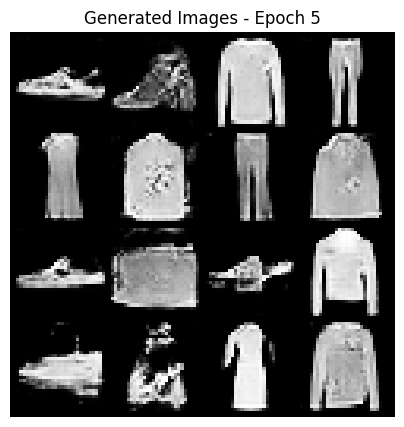

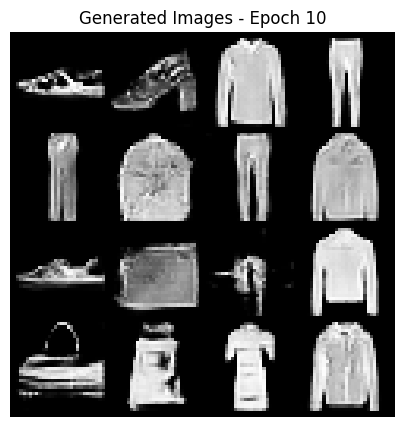

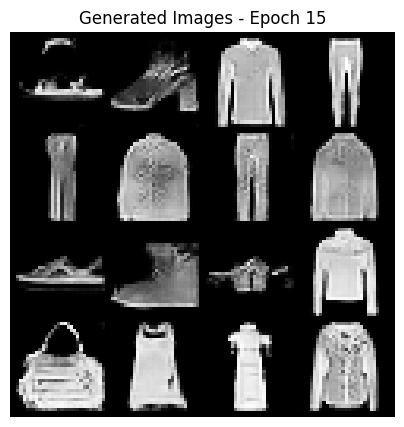

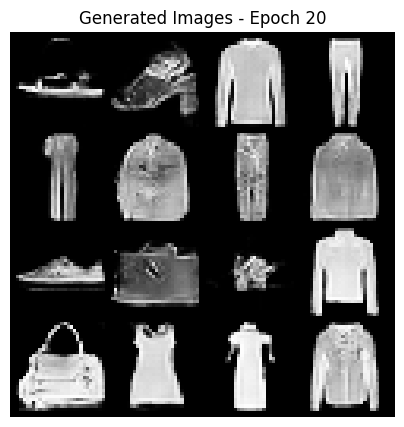

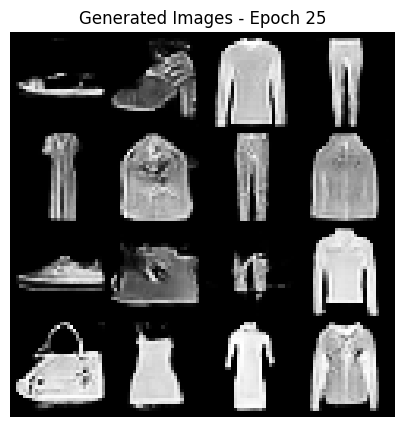

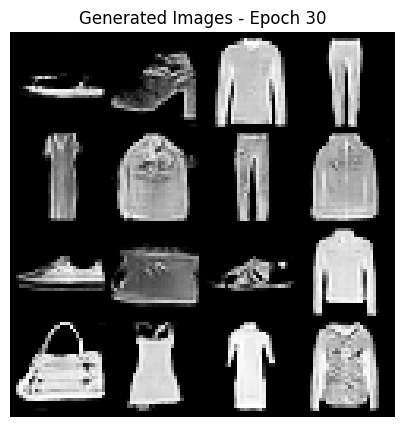

In [15]:
# ============================================
# Cell 13: Display Generated Images From All Epochs
# ============================================

epochs_to_show = [5, 10, 15, 20, 25, 30]

for epoch in epochs_to_show:

    image_path = f"generated_images/epoch_{epoch}.png"

    image = plt.imread(image_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Generated Images - Epoch {epoch}")
    plt.show()

In [16]:
# ============================================
# Cell 14: Check Saved Images
# ============================================

print("Saved generated image grids:")

for epoch in epochs_to_show:
    path = f"generated_images/epoch_{epoch}.png"

    if os.path.exists(path):
        print(f"✓ Epoch {epoch}: {path}")
    else:
        print(f"✗ Epoch {epoch}: Missing")

Saved generated image grids:
✓ Epoch 5: generated_images/epoch_5.png
✓ Epoch 10: generated_images/epoch_10.png
✓ Epoch 15: generated_images/epoch_15.png
✓ Epoch 20: generated_images/epoch_20.png
✓ Epoch 25: generated_images/epoch_25.png
✓ Epoch 30: generated_images/epoch_30.png


# Analysis and Observations

## 1. Early Epochs

During the early epochs, the generated images were mostly random and blurry. The Generator had not yet learned the important visual patterns of the Fashion-MNIST dataset. The clothing shapes were not clearly recognizable.

## 2. Improvement During Training

As training progressed, the generated images gradually became more structured. The Generator learned features such as edges, shapes, and silhouettes of different clothing items. The images became more similar to Fashion-MNIST samples.

## 3. Appearance of Recognizable Clothing

Recognizable clothing-like shapes started appearing as the training progressed. Items such as shoes, shirts, trousers, and bags became easier to identify in the generated images.

## 4. Image Quality Over Time

Image quality improved considerably during the initial and middle stages of training. Towards the later epochs, the improvement became smaller, suggesting that the Generator was approaching a stable level of performance.

## 5. Mode Collapse and Training Stability

The generated images were compared across different epochs to check for mode collapse. Mode collapse occurs when the Generator produces very similar images repeatedly. The generated grids were examined for diversity and variation between samples.

## 6. Loss Behaviour

The Generator and Discriminator losses did not necessarily decrease smoothly. This is expected because GAN training is a competitive process. The Generator tries to produce realistic images while the Discriminator tries to distinguish real images from generated ones.

## Overall Observation

The DCGAN successfully learned to generate Fashion-MNIST-like images from random noise. The generated images became progressively more structured and recognizable as training continued. Comparing the 4×4 grids at epochs 5, 10, 15, 20, 25, and 30 helped demonstrate how the Generator improved throughout training.